In [ ]:
# Google Colab only (does nothing elsewhere): fetch the bundle next to this notebook and install pPXF.
import os, sys, subprocess
os.environ.setdefault("OMP_NUM_THREADS", "1"); os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")     # one core on Colab / Binder
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ppxf", "fitsio", "ipywidgets"], check=True)
    if not os.path.exists("interbars_students"):
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/EdoBorsato/INTERBARS_classes"], check=True)
    os.chdir("interbars_students/notebooks"); print("Colab: working in", os.getcwd())

# Lecture 2 — From the archive to the BPT diagram: barred and interacting galaxies

Last time you took spectra apart and saw how pPXF models them. Today you do the real measurement, start to finish,
on **your own galaxies** — after a warm-up:

0. **build a galaxy by hand**: choose the template weights yourself and see the spectrum (pPXF run backwards);
1. choose a system of the sample (a barred galaxy, with its companion if it has one);
2. **find** its spectra in the SDSS and DESI archives and **download** them;
3. prepare them for pPXF and **run the fit** — stars and gas, the model of lecture 1, now in the forward direction;
4. turn the fitted gas weights into **line fluxes** and line ratios;
5. place your nuclei on the **BPT diagram** over two reference populations from SDSS: **barred galaxies**
   (Nair & Abraham 2010) and **interacting pairs** (a companion within 30 kpc and 500 km/s) — and decide:
   is your nucleus star-forming or AGN, and does it look like a typical barred galaxy, a typical
   interacting one, or neither?

In [1]:
import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):    # one BLAS thread: on Binder / Colab the pod has
    os.environ.setdefault(_v, "1")                                          # one core and multi-threaded BLAS is 30x slower
import io, sys, json
from pathlib import Path
import numpy as np, pandas as pd, requests, fitsio
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from ppxf.ppxf import ppxf

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))
os.environ.setdefault("DESI_SPECTRO_REDUX", str(ROOT / "output" / "desi_redux"))
import lecture_tools as LT                # readers, pPXF input preparation, line fluxes, the BPT frame
import run_ppxf as RP                     # the project's spectrum inventory and production fit
import bpt_comparison as BC               # the SDSS comparison populations (pairs, barred galaxies)
import plot_bpt_ppxf as PB                # the sample's BPT plotting
DL = ROOT / "output" / "downloads"; DL.mkdir(parents=True, exist_ok=True)
(ROOT / "output" / "notebooks").mkdir(parents=True, exist_ok=True)       # where your results table is saved
ONLINE = True            # False = never touch the network: every spectrum, image and catalogue is already in the course folder
NET_TIMEOUT = 15         # seconds; after the first failed request the notebook switches itself to offline mode
C_KMS = 299792.458
COSMO = FlatLambdaCDM(H0=70, Om0=0.3)
STAGE = {0: "pre-interaction", 1: "merger", 2: "post-merger"}
plt.rcParams.update({"figure.dpi": 100})
targets = pd.read_csv(ROOT / "dataset/catalogs/interbars_targets.csv").set_index("system").drop(LT.COURSE_EXCLUDE, errors="ignore")
specz = pd.read_csv(ROOT / "dataset/catalogs/interbars_specz.csv").set_index("system")
inventory = LT.inventory()
print("repo:", ROOT, "| pPXF", __import__("ppxf").__version__)

repo: /home/eborsato/PyAutoThings/workspace/interbars | pPXF 9.5.0


# Part 0 — Build your own galaxy

Last time pPXF took a spectrum and found the template weights. Now run it **backwards**: you choose the
weights, the kinematics, the gas and the dust, and the code builds the spectrum. The next cell rebuilds the
ingredients of lecture 1, Part 1 (the IC 3147B DESI grid, the E-MILES templates, `ssp`, `broaden`, the gas
templates).

In [2]:
from ppxf.ppxf import attenuation
import ppxf.ppxf_util as util
lam_v, flux, ivar, fwhm, mask, z, src = LT.read("IC3147B")
P = LT.prepare(lam_v, flux, ivar, fwhm, mask, z)                         # templates at the DESI resolution of IC 3147B
sps = P["sps"]; velscale = P["velscale"]; lam = sps.lam_temp; AGES, METALS = sps.age_grid[:, 0], sps.metal_grid[0]
gas_t, gas_names, line_wave = util.emission_lines(sps.ln_lam_temp, [3500, 9600], P["fwhm_gal"], tie_balmer=False, limit_doublets=False)
gas_names = list(gas_names)

def ssp(age, metal=0.0):                                                 # the template closest to (age [Gyr], [M/H]); mean 1 at 5070-5950 Å
    i = np.argmin(abs(np.log10(AGES) - np.log10(age))); j = np.argmin(abs(METALS - metal)); return sps.templates[:, i, j]

def broaden(spec, V=0.0, sigma=0.0):                                     # Gaussian LOSVD (mean V, width sigma [km/s]) by FFT, as in lecture 1
    n = spec.size; npad = 2 ** int(np.ceil(np.log2(2 * n))); w = 2 * np.pi * np.fft.rfftfreq(npad)
    return np.fft.irfft(np.fft.rfft(spec, npad) * np.exp(-1j * w * V / velscale - 0.5 * (w * sigma / velscale) ** 2), npad)[:n]

Emission lines included in gas templates:
['H10' 'H9' 'H8' 'Heps' 'Hdelta' 'Hgamma' 'Hbeta' 'Halpha' '[OII]3726'
 '[OII]3729' '[SII]6716' '[SII]6731' '[NeIII]3968' '[NeIII]3869'
 'HeII4687' 'HeI5876' '[OIII]5007_d' '[OI]6300_d' '[NII]6583_d']
Emission lines included in gas templates:
['H10' 'H9' 'H8' 'Heps' 'Hdelta' 'Hgamma' 'Hbeta' 'Halpha' '[OII]3726'
 '[OII]3729' '[SII]6716' '[SII]6731' '[NeIII]3968' '[NeIII]3869'
 'HeII4687' 'HeI5876' '[OIII]5007_d' '[OI]6300_d' '[NII]6583_d']


## 0.1 The machine

`make_galaxy` is the pPXF model written out by hand. You give it

* `stars`: a dictionary `{(age in Gyr, [M/H]): light fraction}`, e.g. `{(10, 0.0): 0.7, (0.3, 0.0): 0.3}`;
* `sigma_star`, `sigma_gas`: velocity dispersions [km/s];
* `gas`: line fluxes. The helper `gas_lines` builds them from the quantities you will meet on the BPT:
  the Hα flux and the line ratios $\log$([N II]/Hα), $\log$([O III]/Hβ), $\log$([S II]/Hα), $\log$([O I]/Hα).
  Fluxes are in units of (stellar flux at 5500 Å) × Å, so `ha=20` means an Hα line about 20 Å in
  equivalent width — a modestly star-forming nucleus;
* `broad`: optional broad Hα and Hβ fluxes from gas orbiting a black hole (a type 1 AGN), with `sigma_broad`;
* `A_V`: dust in front of the gas (the stars get 0.44 × of it);
* `snr`: signal-to-noise ratio per pixel (`None` = no noise).

It returns the spectrum and its pieces; `LT.show_mock` draws them, with the position of the gas on the BPT.

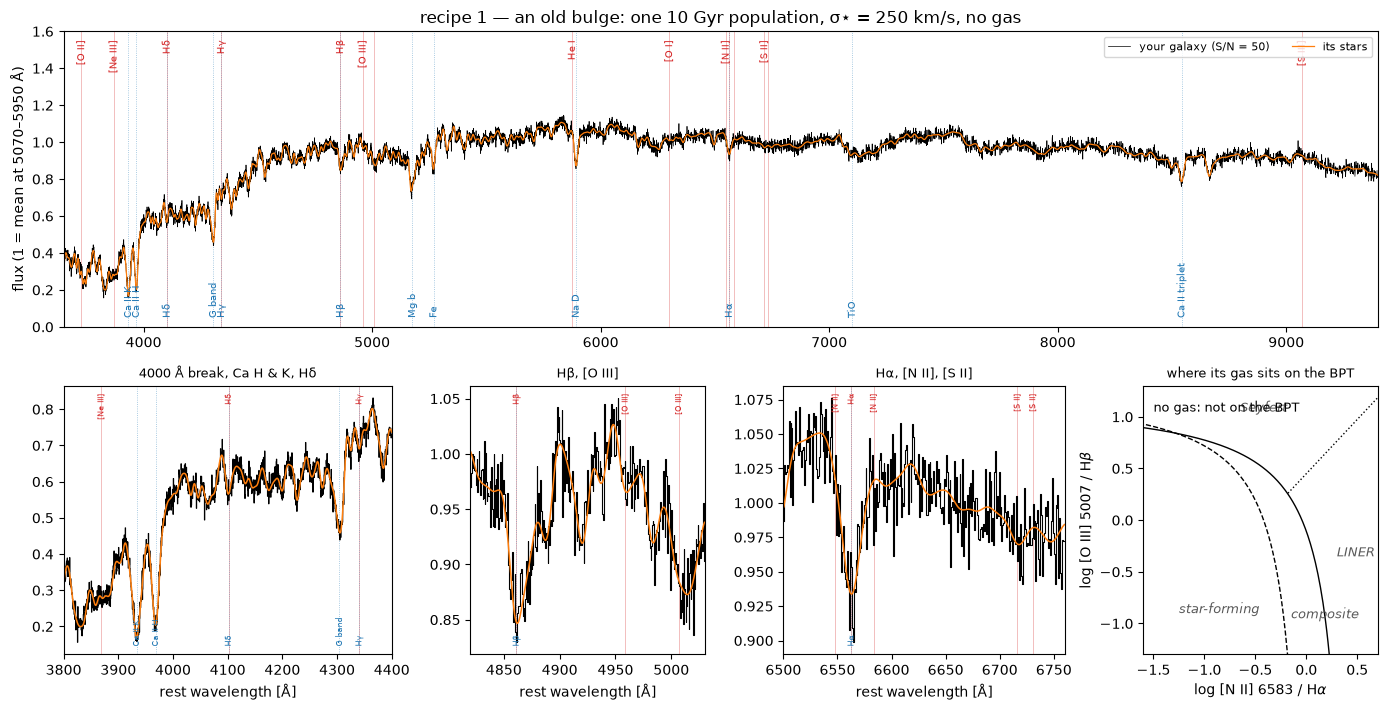

In [3]:
def gas_lines(ha=20.0, nii_ha=-0.45, oiii_hb=-0.3, sii_ha=-0.45, oi_ha=-1.5, oii_hb=0.3, balmer=2.86):
    # emission-line fluxes from Hα and the log line ratios (case-B Balmer series: Hα : Hβ : Hγ : Hδ = 2.86 : 1 : 0.47 : 0.26)
    hb = ha / balmer
    return {"Halpha": ha, "Hbeta": hb, "Hgamma": 0.468 * hb, "Hdelta": 0.259 * hb,
            "[NII]6583_d": ha * 10 ** nii_ha, "[OIII]5007_d": hb * 10 ** oiii_hb, "[OI]6300_d": ha * 10 ** oi_ha,
            "[SII]6716": 0.58 * ha * 10 ** sii_ha, "[SII]6731": 0.42 * ha * 10 ** sii_ha,
            "[OII]3726": 0.42 * hb * 10 ** oii_hb, "[OII]3729": 0.58 * hb * 10 ** oii_hb}

def make_galaxy(stars, sigma_star=150.0, gas=None, sigma_gas=80.0, broad=None, sigma_broad=2000.0, A_V=0.0, snr=None, V=0.0, seed=1):
    
    st = sum(w * ssp(age, met) for (age, met), w in stars.items())                     # sum_j w_j T_j
    
    st = broaden(st, V, sigma_star) * attenuation(lam, 0.44 * A_V)                        # * LOSVD_stars, dust
    
    g = np.zeros_like(lam)
    for name, flux in (gas or {}).items():                                                # sum_k g_k E_k: weight = flux / pixel size [Å]
        k = gas_names.index(name); g += flux / (line_wave[k] * velscale / C_KMS) * gas_t[:, k]
        
    g = broaden(g, V, sigma_gas)
    for name, flux in (broad or {}).items():                                              # broad lines: same templates, much larger sigma
        k = gas_names.index(name); g += broaden(flux / (line_wave[k] * velscale / C_KMS) * gas_t[:, k], V, sigma_broad)
        
    g = g * attenuation(lam, A_V)     
    # dust in front of the gas
    total = st + g
    
    noisy = total + (np.random.default_rng(seed).normal(0, 1 / snr, lam.size) if snr else 0.0)
    
    obs = {k: f * np.interp(line_wave[gas_names.index(k)], lam, attenuation(lam, A_V)) for k, f in (gas or {}).items()}   # what a telescope measures
    
    bpt = (np.log10(obs["[NII]6583_d"] / obs["Halpha"]), np.log10(obs["[OIII]5007_d"] / obs["Hbeta"])) if gas else (np.nan, np.nan)
    
    return dict(lam=lam, stars=st, gas=g, total=total, flux=noisy, snr=snr, bpt=bpt, observed_lines=obs,
                inputs=dict(stars=stars, sigma_star=sigma_star, sigma_gas=sigma_gas, A_V=A_V))

old_bulge = make_galaxy({(10, 0.0): 1}, sigma_star=300, snr=50)

LT.show_mock(old_bulge, "recipe 1 — an old bulge: one 10 Gyr population, σ⋆ = 250 km/s, no gas")

## 0.2 Recipes

Each cell is a galaxy. Run it, look, then **change the numbers** and see what moves.

**A star-forming nucleus.** Young stars dominate the blue light, and the gas is ionised by them.

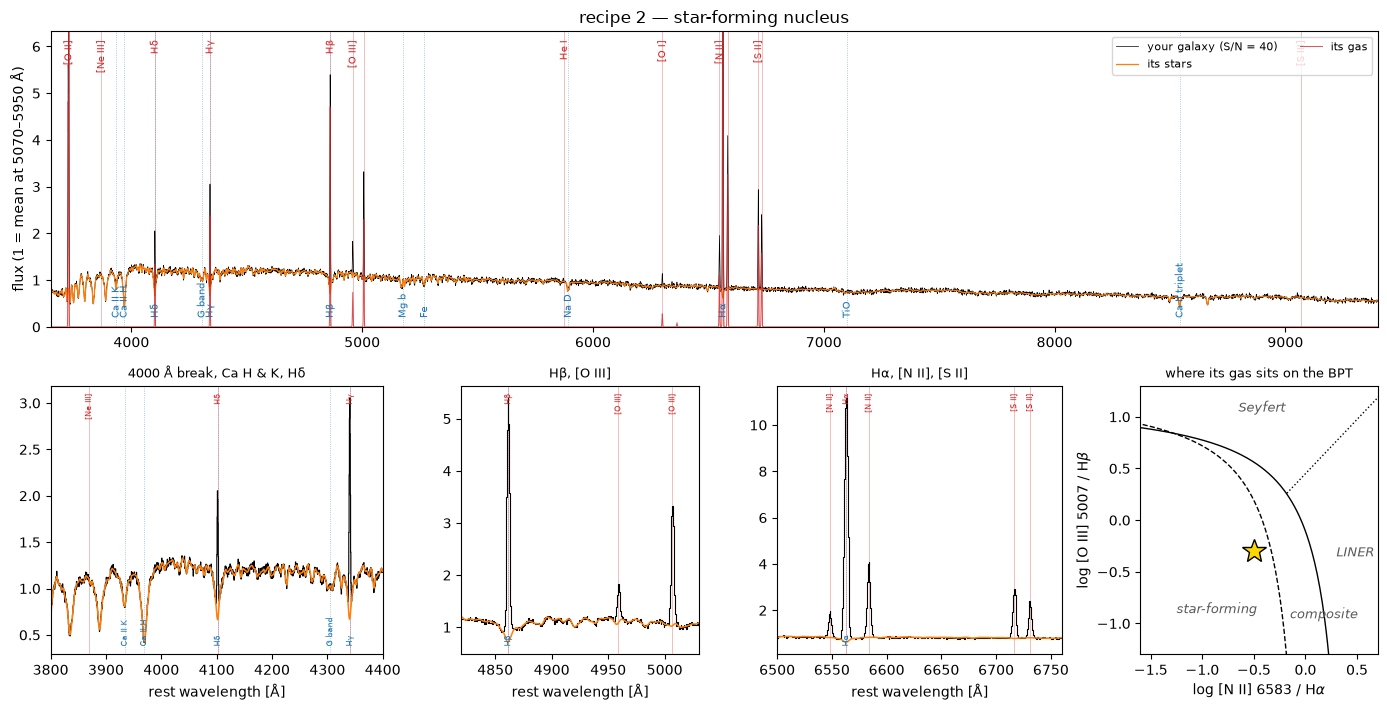

In [4]:
sf_nucleus = make_galaxy({(0.1, 0.0): 0.4, (1, 0.0): 0.2, (10, 0.0): 0.4}, sigma_star=80,
                         gas=gas_lines(ha=40, nii_ha=-0.5, oiii_hb=-0.3, sii_ha=-0.45, oi_ha=-1.6), sigma_gas=60, snr=40)
LT.show_mock(sf_nucleus, "recipe 2 — star-forming nucleus")

* Raise `ha` from 40 to 200: which features of the stars disappear under the gas?
* Add dust, `A_V=1.5`: the continuum reddens and Hα/Hβ grows, but does the star move on the BPT? Why not?

**A Seyfert 2 in an old bulge.** Old, metal-rich stars; gas ionised by an AGN, stirred to σ = 250 km/s.

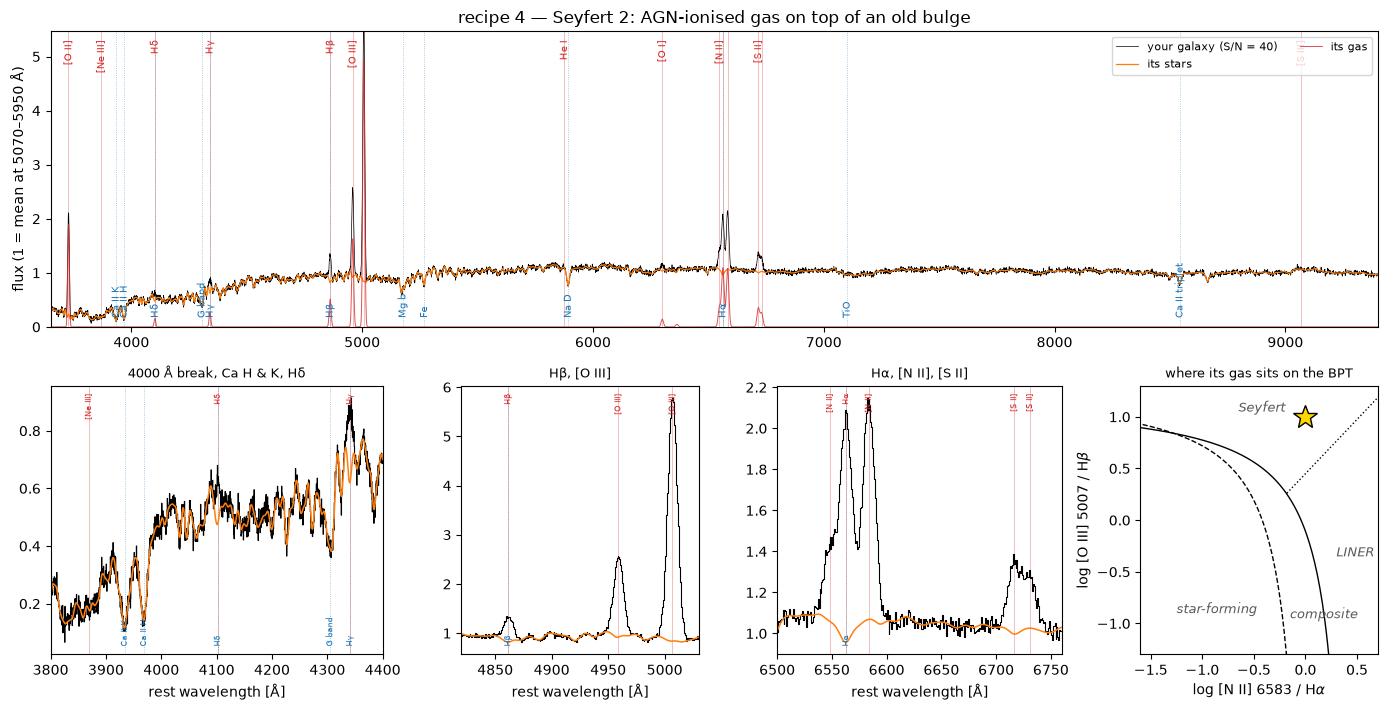

In [5]:
seyfert2 = make_galaxy({(12, 0.22): 1.0}, sigma_star=200,
                       gas=gas_lines(ha=15, nii_ha=0.0, oiii_hb=1.0, sii_ha=-0.25, oi_ha=-0.9, oii_hb=0.5), sigma_gas=250, snr=40)
LT.show_mock(seyfert2, "recipe 4 — Seyfert 2: AGN-ionised gas on top of an old bulge")

* Reduce `oiii_hb` until the star crosses the Kewley line. What would you call the nucleus then?
* Make a **LINER**: weak lines (`ha=3`), `nii_ha=0.2`, `oiii_hb=0.0`, `oi_ha=-0.5`, `snr=15`. Can you still see the lines?

## 0.3 Challenge: build the nucleus of IC 3147B by hand

Now the real thing, still backwards. Below is the DESI spectrum of IC 3147B in its rest frame (grey). Choose
the populations, σ⋆, the gas and the dust so that your galaxy (black) matches it. The number to beat is the
**χ² per pixel**, $\chi^2/N = \frac{1}{N}\sum_i \big[(G_i - G_{{\rm model},i})/\sigma_i\big]^2$: about 1 means
"as good as the noise allows". It is printed twice: on the whole spectrum, and on the stellar continuum only
(emission lines masked), so you can work on the stars first.

Hints: lecture 1 (Appendix A.2) showed a nucleus with young stars *and* old ones, whose lines are those of a composite (Appendix A.4); σ⋆
is 70–100 km/s; Hα/Hβ ≈ 4 in this spectrum (what does that say about $A_V$?).

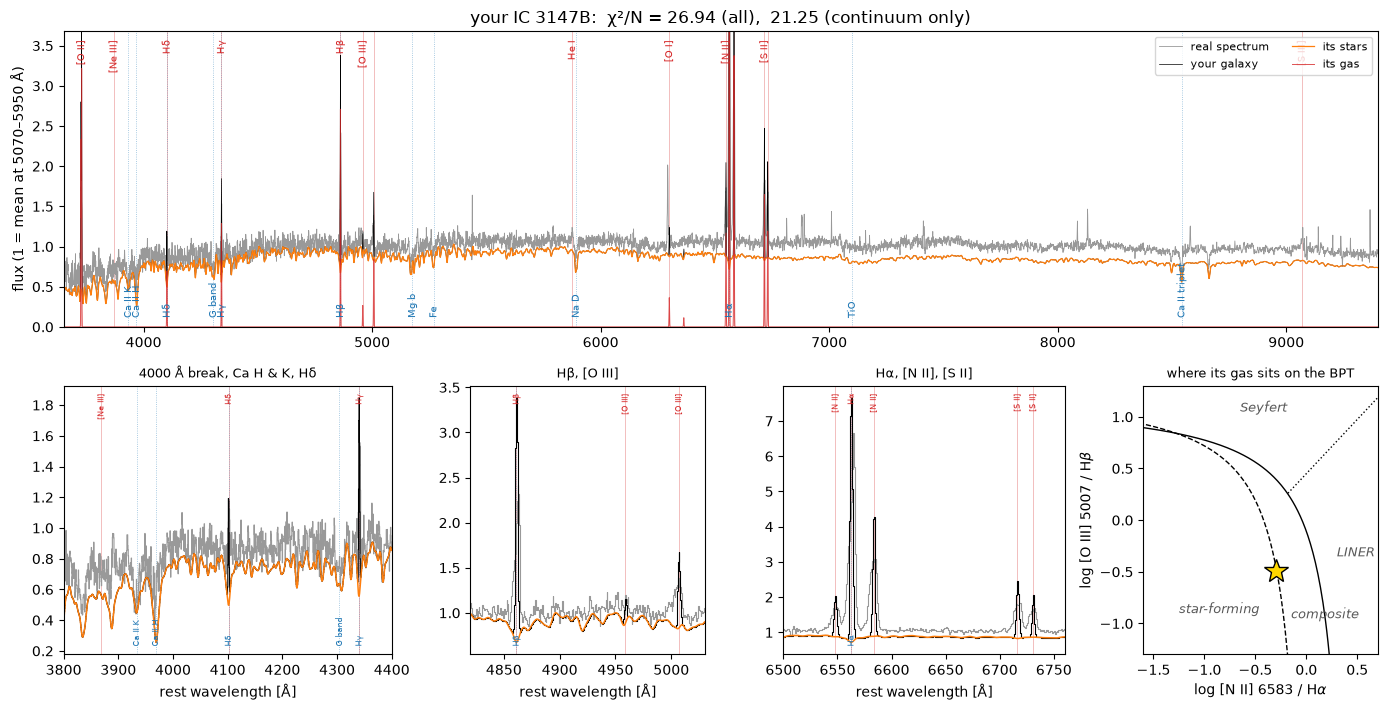

In [6]:
rest = P["lam_gal"] / (1 + z); data = P["galaxy"]; err = P["noise"]
fit_px = np.zeros(rest.size, bool); fit_px[P["goodpixels"]] = True; fit_px &= (rest > 3700) & (rest < 9200)
lines_px = np.zeros(rest.size, bool)
for _, w0 in LT.EMISSION:
    lines_px |= abs(rest - w0) < 15
scale = np.median(data[(rest > 5070) & (rest < 5950)])                       # the data's flux at 5500 Å: model unit -> data unit

def score(m, show=True, title="your IC 3147B"):
    model = np.interp(rest, m["lam"], m["total"]) * scale
    chi = ((data - model) / err) ** 2
    c_all, c_cont = chi[fit_px].mean(), chi[fit_px & ~lines_px].mean()
    if show:
        LT.show_mock(dict(m, flux=m["total"] * scale, stars=m["stars"] * scale, gas=m["gas"] * scale), f"{title}:  χ²/N = {c_all:.2f} (all),  {c_cont:.2f} (continuum only)", data=(rest, data))
    return c_all, c_cont

my_guess = make_galaxy({(0.1, 0.0): 0.25, (10, 0.2): 0.75}, sigma_star=100,             # <-- change these
                       gas=gas_lines(ha=25, nii_ha=-0.3, oiii_hb=-0.5, sii_ha=-0.4, oi_ha=-1.3), sigma_gas=40, A_V=0.35)
score(my_guess);

Keep a note of your best χ²/N and of the weights that gave it.

### pPXF's answer

Now the forward direction: pPXF searches *all* 150 templates, σ, V, the gas fluxes and $A_V$ at once —
the same model as `make_galaxy`, so the χ² is directly comparable with yours. (In lecture 2 the fit will
also include a smooth polynomial to absorb small flux-calibration errors; here we leave it out to keep the
two models identical.)

pPXF: χ²/N = 1.98 (all), 1.17 (continuum only)
      σ⋆ = 74 km/s, σ_gas = 129 / 151 km/s (Balmer / forbidden), A_V stars = 0.67
      Hα/Hβ = 3.99 (2.86 without dust)
light fractions by age (summed over metallicity), > 1 %:
0.063     0.046
0.158     0.189
1.585     0.210
3.981     0.073
10.000    0.349
15.849    0.129


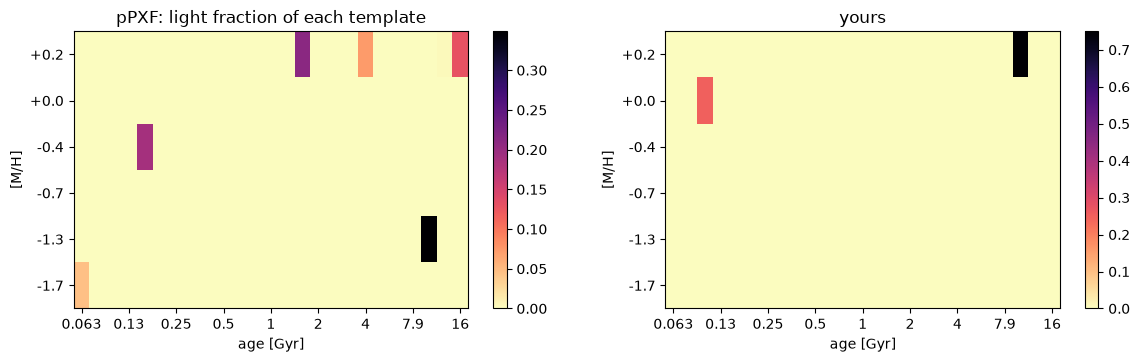

In [7]:
stars_t = sps.templates.reshape(sps.templates.shape[0], -1); n_st = stars_t.shape[1]
forb = np.array(["[" in n for n in gas_names])
templates = np.column_stack([stars_t, gas_t]); component = [0] * n_st + [2 if f else 1 for f in forb]
vel = C_KMS * np.log(1 + z)
pp = ppxf(templates, data, err, velscale, [[vel, 100], [vel, 80], [vel, 80]], moments=[2, 2, 2], degree=-1, mdegree=-1,
          lam=P["lam_gal"], lam_temp=lam, component=component, gas_component=np.array(component) > 0, gas_names=np.array(gas_names),
          goodpixels=np.where(fit_px)[0], reddening=0.2, quiet=True)
chi = ((data - pp.bestfit) / err) ** 2
print(f"pPXF: χ²/N = {chi[fit_px].mean():.2f} (all), {chi[fit_px & ~lines_px].mean():.2f} (continuum only)")
print(f"      σ⋆ = {pp.sol[0][1]:.0f} km/s, σ_gas = {pp.sol[1][1]:.0f} / {pp.sol[2][1]:.0f} km/s (Balmer / forbidden), A_V stars = {pp.reddening:.2f}")
ha_hb = pp.gas_flux[gas_names.index("Halpha")] / pp.gas_flux[gas_names.index("Hbeta")] * 6563 / 4861    # weights are per pixel; pixel size [Å] grows with λ
print(f"      Hα/Hβ = {ha_hb:.2f} (2.86 without dust)")
w = pp.weights[:n_st].reshape(sps.templates.shape[1:]); w = w / w.sum()
by_age = pd.Series(w.sum(1), index=AGES.round(3)); print("light fractions by age (summed over metallicity), > 1 %:"); print(by_age[by_age > 0.01].round(3).to_string())
fig, axs = plt.subplots(1, 2, figsize=(14, 3.6))
im = LT.light_map(axs[0], w, AGES, METALS, "pPXF: light fraction of each template"); plt.colorbar(im, ax=axs[0])
yours = np.zeros_like(w)
for (age, met), f in my_guess["inputs"]["stars"].items():
    yours[np.argmin(abs(np.log10(AGES) - np.log10(age))), np.argmin(abs(METALS - met))] += f
im = LT.light_map(axs[1], yours / yours.sum(), AGES, METALS, "yours"); plt.colorbar(im, ax=axs[1]); plt.show()

**Discuss**: did pPXF beat you? Does it use the same ages you chose? It usually spreads the light over
many templates, some of which you would never have picked — part of this is real (a galaxy has a continuous
star-formation history), part is the **degeneracies** of B.1 and B.5: different mixtures that produce
almost the same spectrum within the noise.

## 0.4 (if time) The loop closed: can pPXF recover *your* galaxy?

You know the true answer for a mock galaxy. Give it to pPXF and compare what it finds with what you put in.
Repeat at different S/N.

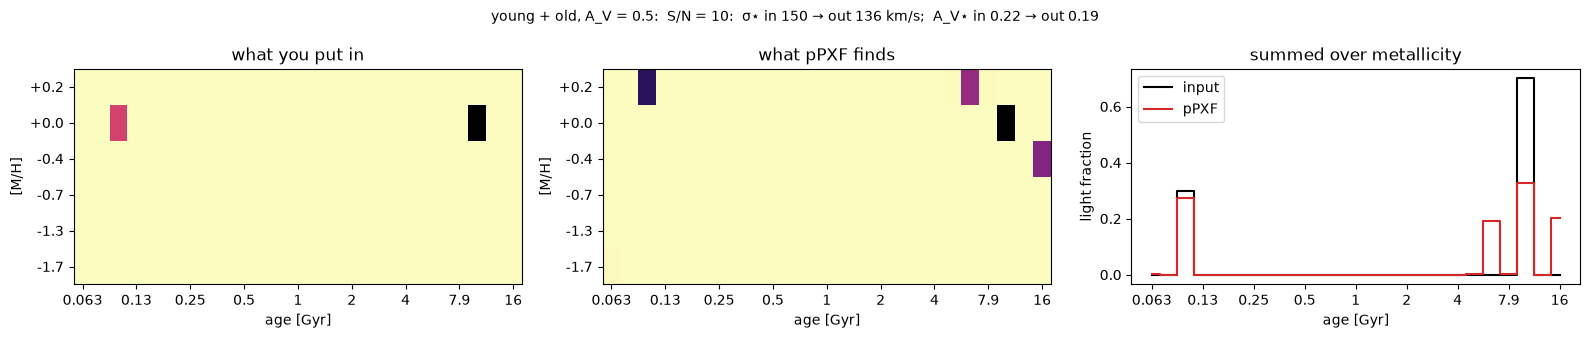

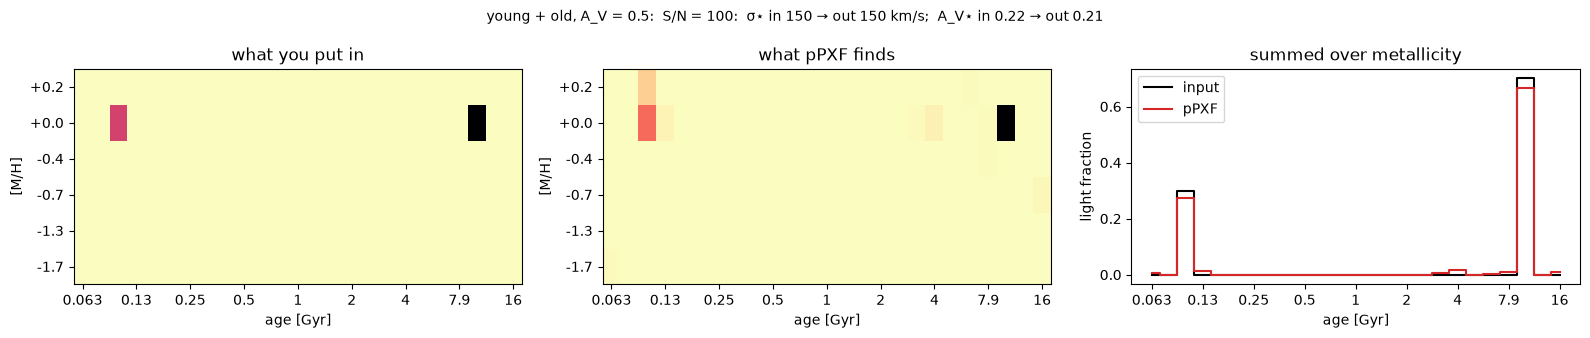

In [8]:
def recover(m, title=""):
    s = (m["lam"] > 3700) & (m["lam"] < 9300)                     # a stretch of the mock as the "observed" spectrum
    noise = np.full(s.sum(), 1 / m["snr"]); has_gas = bool(m["observed_lines"])
    tpl = np.column_stack([stars_t, gas_t]) if has_gas else stars_t
    comp = component if has_gas else [0] * n_st
    pp = ppxf(tpl, m["flux"][s], noise, velscale, [[0, 100], [0, 80], [0, 80]] if has_gas else [0, 100], moments=[2, 2, 2] if has_gas else 2,
              degree=-1, mdegree=-1, lam=m["lam"][s], lam_temp=lam, component=comp, gas_component=np.array(comp) > 0,
              gas_names=np.array(gas_names) if has_gas else None, reddening=0.1, quiet=True)
    w = pp.weights[:n_st].reshape(sps.templates.shape[1:]); w = w / w.sum()
    truth = np.zeros_like(w)
    for (age, met), f in m["inputs"]["stars"].items():
        truth[np.argmin(abs(np.log10(AGES) - np.log10(age))), np.argmin(abs(METALS - met))] += f
    truth /= truth.sum()
    sol = pp.sol[0] if has_gas else pp.sol
    fig, axs = plt.subplots(1, 3, figsize=(16, 3.4))
    LT.light_map(axs[0], truth, AGES, METALS, "what you put in"); LT.light_map(axs[1], w, AGES, METALS, "what pPXF finds")
    axs[2].step(np.arange(len(AGES)), truth.sum(1), where="mid", color="k", label="input"); axs[2].step(np.arange(len(AGES)), w.sum(1), where="mid", color="tab:red", label="pPXF")
    axs[2].set_xticks(range(0, len(AGES), 3)); axs[2].set_xticklabels([f"{a:.2g}" for a in AGES[::3]]); axs[2].set(xlabel="age [Gyr]", ylabel="light fraction", title="summed over metallicity"); axs[2].legend()
    fig.suptitle(f"{title}  S/N = {m['snr']}:  σ⋆ in {m['inputs']['sigma_star']:.0f} → out {sol[1]:.0f} km/s;  A_V⋆ in {0.44 * m['inputs']['A_V']:.2f} → out {pp.reddening:.2f}", fontsize=10)
    fig.tight_layout(); plt.show()

for snr in (10, 100):
    recover(make_galaxy({(0.1, 0.0): 0.3, (10, 0.0): 0.7}, sigma_star=150, gas=gas_lines(ha=20), A_V=0.5, snr=snr, seed=snr), "young + old, A_V = 0.5:")

**Questions** (if time)

1. At S/N = 10 the recovered weights scatter to neighbouring ages and metallicities. Is the *mean* age still right?
2. Which numbers are robust — σ⋆, the young light fraction, the metallicity, the gas fluxes? This is why we
   trust pPXF for the **emission lines** and the kinematics, and are cautious with detailed star-formation histories.

Now to the real thing: your own galaxies.

## 1. The sample, and your system

27 systems: barred galaxies at $z \approx 0.01$–$0.05$, most with a companion. `class_VC` is the interaction
stage from a visual classification of the images: **0** = pre-interaction (two separate galaxies), **1** =
merger (in contact, tidal bridges), **2** = post-merger (one disturbed remnant). `comp_name` is the companion.

In [9]:
cols = ["z_hand", "class_VC", "comp_name", "comp_z_hand"]
tab = targets[cols].copy(); tab["stage"] = tab.class_VC.map(STAGE)
tab["spectra"] = [", ".join(f"{r.role}:{r.source}" for r in inventory[inventory.system == s].itertuples()) for s in tab.index]
print(tab.round(4).to_string())

                        z_hand  class_VC                 comp_name  comp_z_hand            stage                          spectra
system                                                                                                                           
LEDA181851              0.0207       2.0                       NaN          NaN      post-merger             main:DESI, main:SDSS
2MASXJ09551395+1417576  0.0242       0.0                 PGC028602       0.0244  pre-interaction             main:SDSS, comp:SDSS
IC3378                  0.0453       0.0                    IC3379       0.0452  pre-interaction  main:DESI, main:SDSS, comp:SDSS
2MASXJ11422226+0845548  0.0219       1.0                    IC0720       0.0216           merger             main:SDSS, comp:SDSS
NVSSJ084256+133826      0.0168       1.0  [WGB2006] 084012+13500 b       0.0163           merger                        main:SDSS
IC2810                  0.0340       0.0                   IC2810B       0.0339  pre-inter

Choose **one or two systems** (ask which ones are still free) and write them here. Systems with spectra of
both galaxies of the pair, or of the same galaxy from both surveys, are the most interesting.

**Slow or no internet?** Set `ONLINE = False` in the first code cell and re-run it. The archive search, the
downloads and the images below then come from copies already in the course folder, and everything works the same.

In [68]:
MY_SYSTEMS = ["UGC6142"]                  # <-- your system(s), e.g. ["UGC6142"], ["NGC2864"], ["IC2810", "Z44-80"]
for s_ in MY_SYSTEMS:
    r = targets.loc[s_]
    print(f"{s_}: RA {r.ra:.5f}  Dec {r.dec:.5f}  z = {r.z_hand:.4f}  stage {r.class_VC:.0f} ({STAGE.get(r.class_VC, '?')})"
          + (f";  companion {r.comp_name} at {specz.loc[s_, 'comp_sep_kpc']:.0f} kpc, Δv = {specz.loc[s_, 'dv_comp_kms']:+.0f} km/s" if isinstance(r.comp_name, str) else ";  no companion"))
BROAD_LINE = {"MCG-01-09-041"}                # systems with a broad-line (Seyfert 1) nucleus
if BROAD_LINE & set(MY_SYSTEMS):
    print("\n>>> Your selection includes a Seyfert 1: continue in L2b_broad_lines.ipynb <<<")
mine = inventory[inventory.system.isin(MY_SYSTEMS)]
print(); print(mine[["system", "role", "source", "spec_id", "z_in"]].to_string())

UGC6142: RA 166.17463  Dec 4.29736  z = 0.0252  stage 0 (pre-interaction);  companion UGC6142A at 27 kpc, Δv = +35 km/s

                    system  role source           spec_id      z_in
label                                                              
UGC6142            UGC6142  main   DESI  2842629133828099  0.025197
UGC6142_sdss       UGC6142  main   SDSS      580-52368-28  0.025110
UGC6142_comp_sdss  UGC6142  comp   SDSS     581-52356-304  0.025229


## 2. Find the spectra in the archives

Spectroscopic surveys publish **catalogues** — one row per spectrum, with position, redshift and quality —
that can be queried in SQL (the ADQL dialect) over the web. Both SDSS DR17 and DESI DR1 are served by the
NOIRLab **Astro Data Lab**. We ask for every spectrum within 30″ of each of your galaxies.

In [69]:
def datalab(sql):
    if not ONLINE:
        raise ConnectionError("offline mode")
    r = requests.post("https://datalab.noirlab.edu/tap/sync", data=dict(REQUEST="doQuery", LANG="ADQL", FORMAT="csv", QUERY=sql), timeout=NET_TIMEOUT)
    r.raise_for_status(); return pd.read_csv(io.StringIO(r.text))
    
R = 30 / 3600 # conesearch radius
for s_ in MY_SYSTEMS:
    ra_, dec_ = float(targets.loc[s_, "ra"]), float(targets.loc[s_, "dec"]); dra = R / np.cos(np.radians(dec_))
    box = lambda rc, dc: f"{rc} BETWEEN {ra_ - dra} AND {ra_ + dra} AND {dc} BETWEEN {dec_ - R} AND {dec_ + R}"
    try:
        sdss = datalab(f"SELECT plate, mjd, fiberid, ra, dec, z, zwarning, class FROM sdss_dr17.specobj WHERE {box('ra', 'dec')}")
        desi = datalab(f"SELECT targetid, mean_fiber_ra AS ra, mean_fiber_dec AS dec, z, zwarn, spectype, survey, program, healpix, zcat_primary FROM desi_dr1.zpix WHERE {box('mean_fiber_ra', 'mean_fiber_dec')}")
        for name, d in (("SDSS DR17", sdss), ("DESI DR1", desi)):
            d["sep_arcsec"] = 3600 * np.hypot((d.ra - ra_) * np.cos(np.radians(dec_)), d.dec - dec_)
            print(f"== {s_} / {name}: {len(d)} spectra within 30\""); print(d.sort_values("sep_arcsec").round(5).to_string(index=False) if len(d) else "   none"); print()
    except Exception as e:
        if ONLINE: print(f"archive not reachable ({e.__class__.__name__}): switching to offline mode"); ONLINE = False
        print(f"{s_}: the same search, saved in the course folder:")
        m = pd.read_csv(ROOT / "dataset/catalogs/specz_matches.csv"); print(m[(m.system == s_) & (m.sep_arcsec < 30) & m.survey.isin(["SDSS DR17", "DESI DR1"])][["survey", "obj_id", "z", "sep_arcsec"]].to_string(index=False))

== UGC6142 / SDSS DR17: 1 spectra within 30"
 plate   mjd  fiberid        ra     dec       z  zwarning  class  sep_arcsec
   580 52368       28 166.17465 4.29733 0.02511         0 GALAXY     0.14616

== UGC6142 / DESI DR1: 3 spectra within 30"
         targetid        ra     dec       z  zwarn spectype survey program  healpix zcat_primary  sep_arcsec
 2842629133828099 166.17464 4.29736 0.02520      0   GALAXY   main    dark    27107            t     0.05365
39627890152705915 166.17731 4.29554 0.02469      0   GALAXY   main  bright    27107            t    11.65261
39627890152705807 166.17234 4.29987 0.02590      0   GALAXY   main  bright    27107            t    12.20388



Things to notice: a galaxy can appear several times (DESI observes some targets in more than one
program — `zcat_primary` marks the best spectrum); rows tens of arcseconds away are other galaxies,
often the companion; `zwarning` / `zwarn` = 0 means the pipeline trusts its redshift.

## 3. Download

**SDSS** stores one small FITS file per spectrum (~200 kB), at an address built from the plate, MJD and fibre
numbers. We download it from the SDSS Science Archive Server (SAS).

**DESI** stores spectra in *healpix coadds*: one file per patch of sky, holding all the targets in it (200–500
MB each). Downloading a whole coadd per student is not practical in class, so the course bundle ships a
copy trimmed to our galaxies (same format, ~1 MB). The cell prints the address of the full public file, so
you can see where it comes from.

In [70]:
SAS = "https://data.sdss.org/sas/dr17"
def download_sdss(label):
    r = inventory.loc[label]; name = Path(r.file).name; p, mj, f = name[5:-5].split("-"); dst = DL / name
    if dst.exists() and dst.stat().st_size > 1e5:
        return dst
    if not ONLINE:
        print(f"   offline mode: using the copy in the course folder ({name})"); return Path(r.file)
    urls = [f"{SAS}/{s}/spectro/redux/{run2d}/spectra/lite/{p}/{name}" for s, run2d in
            [("sdss", r.run2d), ("eboss", r.run2d), ("sdss", "26"), ("sdss", "103"), ("sdss", "104"), ("eboss", "v5_13_2")] if isinstance(run2d, str) and run2d]
    for u in urls:
        try:
            resp = requests.get(u, timeout=NET_TIMEOUT)
        except requests.RequestException:
            globals()["ONLINE"] = False; print("   SDSS server not reachable: switching to offline mode"); break
        if resp.ok and resp.content[:6] == b"SIMPLE":
            dst.write_bytes(resp.content); print(f"   downloaded {u}  ({len(resp.content) / 1e3:.0f} kB)"); return dst
    print(f"   {name}: download failed (offline?) - using the copy in the course bundle"); return Path(r.file)

FILES = {}
for lab, r in mine.iterrows():
    print(f"{lab} ({r.source}):")
    if r.source == "SDSS":
        FILES[lab] = download_sdss(lab)
    else:
        rel = Path(r.file).as_posix().split("iron/healpix/")[1]
        print(f"   full public coadd: https://data.desi.lbl.gov/public/dr1/spectro/redux/iron/healpix/{rel}\n   using the trimmed copy in the bundle: {Path(r.file).name}, TARGETID {r.spec_id}")
        FILES[lab] = Path(r.file)

UGC6142 (DESI):
   full public coadd: https://data.desi.lbl.gov/public/dr1/spectro/redux/iron/healpix/main/dark/271/27107/coadd-main-dark-27107.fits
   using the trimmed copy in the bundle: coadd-main-dark-27107.fits, TARGETID 2842629133828099
UGC6142_sdss (SDSS):
   downloaded https://data.sdss.org/sas/dr17/sdss/spectro/redux/26/spectra/lite/0580/spec-0580-52368-0028.fits  (173 kB)
UGC6142_comp_sdss (SDSS):
   downloaded https://data.sdss.org/sas/dr17/sdss/spectro/redux/26/spectra/lite/0581/spec-0581-52356-0304.fits  (176 kB)


Look inside a file: a FITS file is a list of *HDUs* (header + data). An SDSS "lite" file has the spectrum
in the `COADD` table (`loglam` = log₁₀ wavelength, `flux` in 10⁻¹⁷ erg s⁻¹ cm⁻² Å⁻¹, `ivar` = 1/σ², `wdisp` =
the instrumental line width); a DESI coadd has, per spectrograph arm (B, R, Z), the wavelength, flux, inverse
variance, mask and resolution matrix, and a `FIBERMAP` table saying which row is which target.

In [71]:
for lab, f in FILES.items():
    with fitsio.FITS(f) as F:
        print(f"{lab}: {f.name}"); print("   HDUs:", [h.get_extname() or "(primary)" for h in F][:20])

UGC6142: coadd-main-dark-27107.fits
   HDUs: ['(primary)', 'FIBERMAP', 'EXP_FIBERMAP', 'B_WAVELENGTH', 'B_FLUX', 'B_IVAR', 'B_MASK', 'B_RESOLUTION', 'R_WAVELENGTH', 'R_FLUX', 'R_IVAR', 'R_MASK', 'R_RESOLUTION', 'Z_WAVELENGTH', 'Z_FLUX', 'Z_IVAR', 'Z_MASK', 'Z_RESOLUTION', 'SCORES']
UGC6142_sdss: spec-0580-52368-0028.fits
   HDUs: ['(primary)', 'COADD', 'SPECOBJ', 'SPZLINE']
UGC6142_comp_sdss: spec-0581-52356-0304.fits
   HDUs: ['(primary)', 'COADD', 'SPECOBJ', 'SPZLINE']


### Where did the fibre land?

A fibre spectrum sees only a small disc on the sky — 3″ for SDSS, 1.5″ for DESI. Here it is on a Legacy
Survey colour image of your galaxy (saved in the course folder).

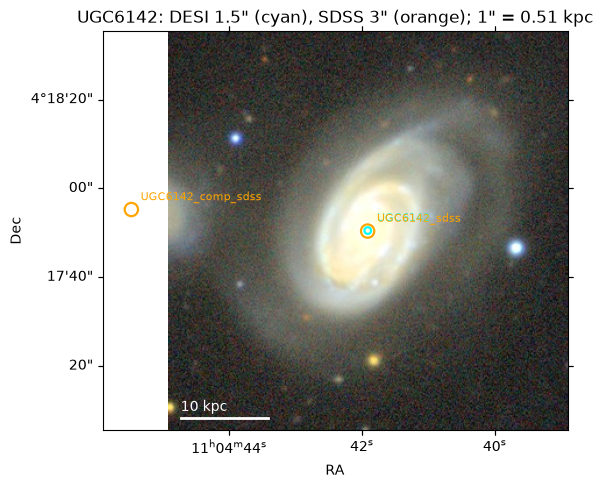

In [72]:
from astropy.wcs import WCS
from PIL import Image
def ls_cutout(ra, dec, size=60.0, pix=0.262):
    name = f"ls_{ra:.5f}_{dec:.5f}_{size:.0f}_{pix}.jpg"
    f = ROOT / "dataset" / "cutouts" / name                                  # shipped with the course folder
    if not f.exists():
        f = ROOT / "output" / "notebooks" / name; f.parent.mkdir(parents=True, exist_ok=True)
    if not f.exists():
        if not ONLINE:
            raise ConnectionError("offline mode and no saved image")
        r = requests.get("https://www.legacysurvey.org/viewer/jpeg-cutout", params=dict(ra=ra, dec=dec, layer="ls-dr10", pixscale=pix, size=int(size / pix)), timeout=NET_TIMEOUT)
        r.raise_for_status(); f.write_bytes(r.content)
    im = np.flipud(np.asarray(Image.open(f)))
    w = WCS(naxis=2); w.wcs.ctype = ["RA---TAN", "DEC--TAN"]; w.wcs.crval = [ra, dec]; w.wcs.crpix = [(im.shape[1] + 1) / 2, (im.shape[0] + 1) / 2]; w.wcs.cdelt = [-pix / 3600, pix / 3600]
    return im, w
for s_ in MY_SYSTEMS:
    try:
        ra_, dec_, z_ = float(targets.loc[s_, "ra"]), float(targets.loc[s_, "dec"]), float(targets.loc[s_, "z_hand"]); kpc = 1 / COSMO.arcsec_per_kpc_proper(z_).value
        im, w = ls_cutout(ra_, dec_, 90.0)
        fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection=w)); ax.imshow(im, origin="lower")
        for lab, r in inventory[inventory.system == s_].iterrows():
            if r.source == "DESI":
                fm = fitsio.read(r.file, "FIBERMAP"); fm = fm[fm["TARGETID"] == int(r.spec_id)][0]; xy, d_, c_ = (fm["MEAN_FIBER_RA"], fm["MEAN_FIBER_DEC"]), 1.5, "cyan"
            else:
                h = fitsio.read_header(FILES.get(lab, r.file), 0); xy, d_, c_ = (h["PLUG_RA"], h["PLUG_DEC"]), 3.0, "orange"
            x, y = w.world_to_pixel_values(*xy); ax.add_patch(plt.Circle((x, y), d_ / 2 / 0.262, fill=False, color=c_, lw=1.6)); ax.text(x + 8, y + 8, lab, color=c_, fontsize=8)
        ax.plot([10, 10 + 10 / kpc / 0.262], [10, 10], color="w", lw=2); ax.text(10, 16, "10 kpc", color="w")
        ax.set(xlabel="RA", ylabel="Dec", title=f"{s_}: DESI 1.5\" (cyan), SDSS 3\" (orange); 1\" = {kpc:.2f} kpc"); plt.show()
    except Exception as e:
        print(f"{s_}: no image ({e.__class__.__name__}: offline?)")

The fibre covers the **nucleus** only — the central kiloparsec or two. The bar, the disc and the tidal
features are outside it: everything below is about the nucleus.

## 4. Look at the spectrum

The readers return the same five arrays for both surveys: vacuum wavelength [Å], flux and inverse variance,
the instrumental FWHM at each pixel [Å] (from the DESI resolution matrix or the SDSS `wdisp`), and a mask of
bad pixels. The spectrum is in the **observed** frame: the lines sit at $\lambda_{\rm rest}(1+z)$.

UGC6142_sdss: SDSS, z = 0.02511, 3813-9213 Å, 3798 good pixels, instrumental FWHM 2.84 Å


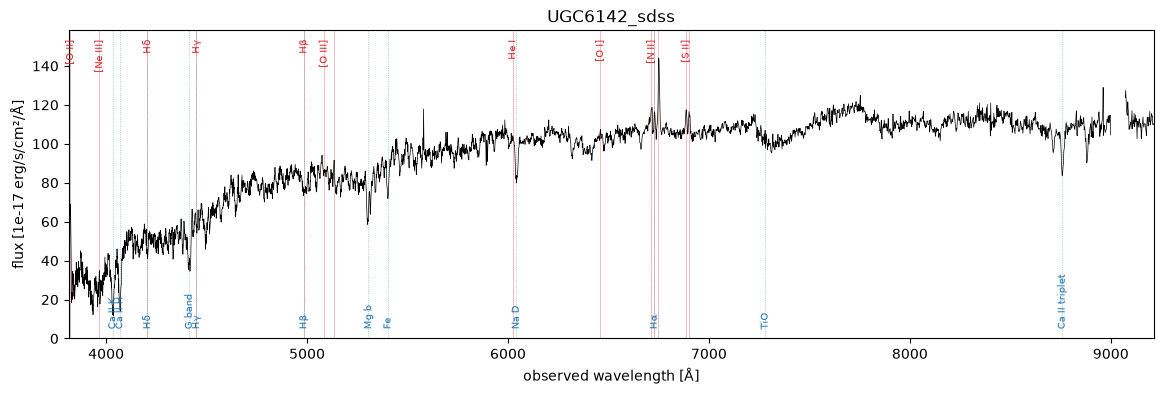

In [79]:
LABEL = mine.index[1]                     # the first spectrum of your list; change to any label of the table above
r = inventory.loc[LABEL]
lam_v, flux, ivar, fwhm, mask = RP.read_desi(r.file, r.spec_id) if r.source == "DESI" else RP.read_sdss(FILES[LABEL])
z = float(r.z_in); good = (ivar > 0) & ~mask
print(f"{LABEL}: {r.source}, z = {z:.5f}, {lam_v[0]:.0f}-{lam_v[-1]:.0f} Å, {good.sum()} good pixels, instrumental FWHM {np.median(fwhm[good]):.2f} Å")
fig, ax = plt.subplots(figsize=(14, 4)); ax.plot(lam_v, np.where(good, flux, np.nan), color="k", lw=0.5)
ax.set(xlim=(lam_v[0], lam_v[-1]), ylim=(0, np.nanpercentile(np.where(good, flux, np.nan), 99.7) * 1.3), xlabel="observed wavelength [Å]", ylabel="flux [1e-17 erg/s/cm²/Å]", title=LABEL)
LT.annotate(ax, z=z); plt.show()

## 5. Prepare the pPXF inputs

Everything from lecture 1, Part 1, in one function (`LT.prepare`, the same steps as the production script
`scripts/run_ppxf.py`):

* **air wavelengths**: the E-MILES templates are tabulated in air, the surveys in vacuum (forgetting it
  shifts every line by ~80 km/s);
* the **logarithmic grid** (`util.log_rebin`): constant `velscale` km/s per pixel; the noise is rebinned too;
* the **stellar templates**: 25 ages × 6 metallicities, degraded to the instrumental resolution of *this*
  spectrum, normalised in the V band (weights = light fractions);
* the **gas templates**, one per line, and the **kinematic components**: 0 = stars, 1 = Balmer lines,
  2 = forbidden lines;
* the **good pixels**: everything except bad pixels, the 5577 Å sky line and the telluric A band.

In [80]:
P = LT.prepare(lam_v, flux, ivar, fwhm, mask, z)
print(f"velscale = {P['velscale']:.1f} km/s/pixel, {P['galaxy'].size} pixels ({P['goodpixels'].size} fitted), "
      f"median S/N per pixel = {np.median(P['galaxy'][P['goodpixels']] / P['noise'][P['goodpixels']]):.1f}")
print(f"{P['n_temps']} stellar templates + {len(P['gas_names'])} gas templates: {list(P['gas_names'])}")

Emission lines included in gas templates:
['H10' 'H9' 'H8' 'Heps' 'Hdelta' 'Hgamma' 'Hbeta' 'Halpha' '[OII]3726'
 '[OII]3729' '[SII]6716' '[SII]6731' '[NeIII]3968' '[NeIII]3869'
 'HeII4687' 'HeI5876' '[OIII]5007_d' '[OI]6300_d' '[NII]6583_d']
velscale = 69.0 km/s/pixel, 3832 pixels (3728 fitted), median S/N per pixel = 38.8
150 stellar templates + 19 gas templates: [np.str_('H10'), np.str_('H9'), np.str_('H8'), np.str_('Heps'), np.str_('Hdelta'), np.str_('Hgamma'), np.str_('Hbeta'), np.str_('Halpha'), np.str_('[OII]3726'), np.str_('[OII]3729'), np.str_('[SII]6716'), np.str_('[SII]6731'), np.str_('[NeIII]3968'), np.str_('[NeIII]3869'), np.str_('HeII4687'), np.str_('HeI5876'), np.str_('[OIII]5007_d'), np.str_('[OI]6300_d'), np.str_('[NII]6583_d')]


## 6. Run pPXF

One call. Compared with lecture 1 there is one new ingredient: `mdegree=10`, a **multiplicative polynomial**
of degree 10 that multiplies the stellar model. It absorbs small errors in the flux calibration and the dust
(so we do not fit `reddening` separately) without touching the strengths of the lines. `bounds` keeps the
narrow lines below σ = 500 km/s.

χ²/N = 0.90
   stars            V =   7443.8 km/s (z = 0.02514)   σ =  171.7 km/s
   Balmer lines     V =   7443.8 km/s (z = 0.02514)   σ =  163.6 km/s
   forbidden lines  V =   7444.4 km/s (z = 0.02514)   σ =  146.4 km/s
   light-weighted age 5.8 Gyr, [M/H] = +0.14


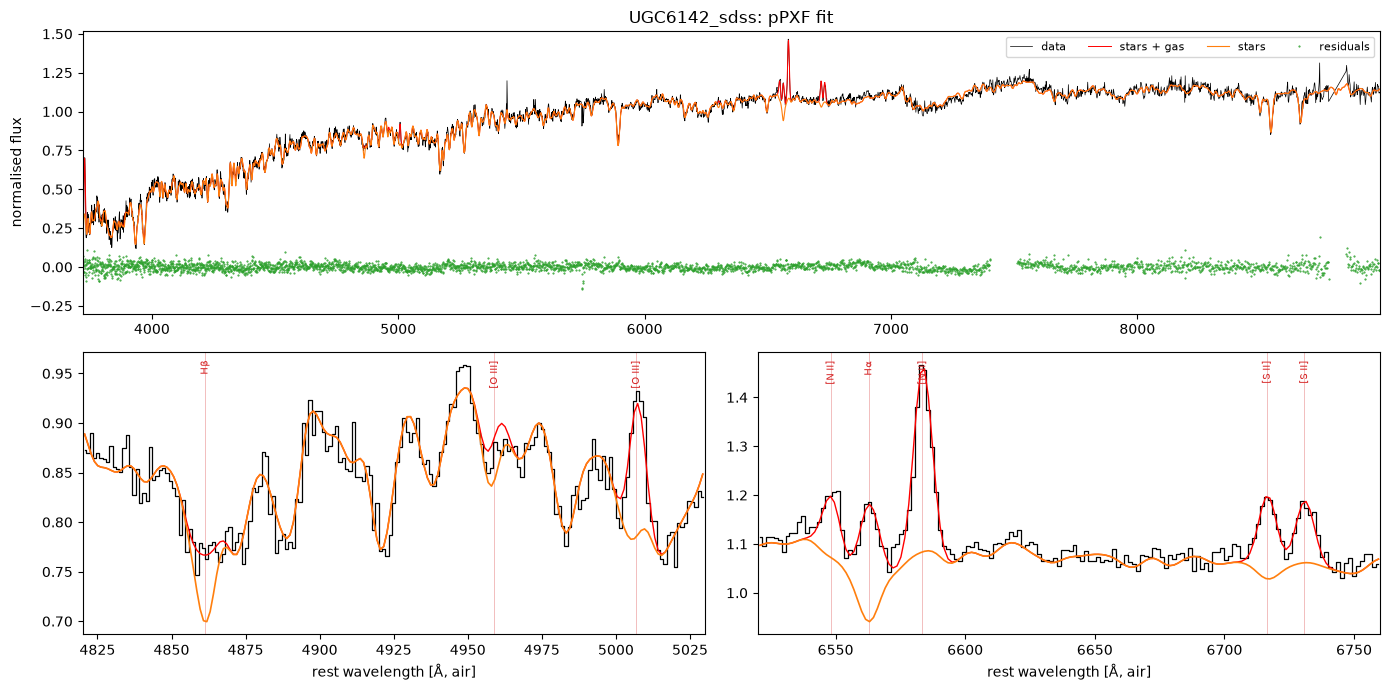

In [81]:
pp = ppxf(P["templates"], P["galaxy"], P["noise"], P["velscale"], P["start"], moments=[2, 2, 2], degree=-1, mdegree=10,
          lam=P["lam_gal"], lam_temp=P["sps"].lam_temp, component=P["component"], gas_component=np.array(P["component"]) > 0,
          gas_names=P["gas_names"], goodpixels=P["goodpixels"], bounds=P["bounds"], quiet=True)
print(f"χ²/N = {pp.chi2:.2f}")
for k, name in enumerate(["stars", "Balmer lines", "forbidden lines"]):
    print(f"   {name:16s} V = {pp.sol[k][0]:8.1f} km/s (z = {np.exp(pp.sol[k][0] / C_KMS) - 1:.5f})   σ = {pp.sol[k][1]:6.1f} km/s")
lg_age, metal = P["sps"].mean_age_metal(pp.weights[:P["n_temps"]].reshape(P["reg_dim"]), quiet=True)
print(f"   light-weighted age {10 ** lg_age / 1e9:.1f} Gyr, [M/H] = {metal:+.2f}")

rest = P["lam_gal"] / (1 + z); stars = pp.bestfit - pp.gas_bestfit
fig = plt.figure(figsize=(14, 7)); gs = fig.add_gridspec(2, 2)
ax = fig.add_subplot(gs[0, :]); ax.plot(rest, P["galaxy"], "k", lw=0.5, label="data"); ax.plot(rest, pp.bestfit, "r", lw=0.7, label="stars + gas")
ax.plot(rest, stars, color="tab:orange", lw=0.8, label="stars"); ax.plot(rest[P["goodpixels"]], (P["galaxy"] - pp.bestfit)[P["goodpixels"]], ".", color="tab:green", ms=1, label="residuals")
ax.set(xlim=(rest[0], rest[-1]), ylim=(-0.3, np.percentile(P["galaxy"], 99.8) * 1.2), ylabel="normalised flux", title=f"{LABEL}: pPXF fit"); ax.legend(ncol=4, fontsize=8)
for k, (lo, hi) in enumerate([(4820, 5030), (6520, 6760)]):
    a = fig.add_subplot(gs[1, k]); s = (rest > lo) & (rest < hi)
    a.plot(rest[s], P["galaxy"][s], "k", lw=0.9, drawstyle="steps-mid"); a.plot(rest[s], pp.bestfit[s], "r", lw=1); a.plot(rest[s], stars[s], color="tab:orange", lw=1.2)
    a.set(xlim=(lo, hi), xlabel="rest wavelength [Å, air]"); LT.annotate(a, kinds=("emission",), fontsize=7)
fig.tight_layout(); plt.show()

Check the fit before trusting it: are the residuals (green) flat noise, or do they show structure under
the lines? Does the orange stellar model follow the absorption features? A **broad** residual under Hα would
point to a type 1 AGN — the production script tests for that with a fourth component (and `L2b_broad_lines.ipynb` shows it).

## 7. From weights to line fluxes, and the BPT ratios

pPXF returns the weight of every gas template in units of the normalised spectrum per pixel; multiplying by
the pixel size in Å and by the normalisation gives fluxes in 10⁻¹⁷ erg s⁻¹ cm⁻² (`LT.line_fluxes`). The BPT
uses $x = \log$([N II] 6583/Hα) and $y = \log$([O III] 5007/Hβ); a line ratio is only trusted when all four
lines have **S/N > 3**.

In [76]:
L = LT.line_fluxes(pp, P); print(L.round(2).to_string())
def bpt_point(L):
    x = np.log10(L.loc["nii", "flux"] / L.loc["ha", "flux"]); y = np.log10(L.loc["oiii", "flux"] / L.loc["hb", "flux"])
    ex = np.hypot(1 / L.loc["nii", "snr"], 1 / L.loc["ha", "snr"]) / np.log(10); ey = np.hypot(1 / L.loc["oiii", "snr"], 1 / L.loc["hb", "snr"]) / np.log(10)
    snr = L.loc[["ha", "hb", "oiii", "nii"], "snr"].min()
    return x, y, ex, ey, snr, (LT.bpt_class(x, y) if snr >= 3 else "low S/N")
x, y, ex, ey, snr, cls = bpt_point(L)
print(f"\nlog([NII]/Hα) = {x:+.3f} ± {ex:.3f}   log([OIII]/Hβ) = {y:+.3f} ± {ey:.3f}   min S/N = {snr:.1f}  ->  {cls}")
print(f"Balmer decrement Hα/Hβ = {L.loc['ha', 'flux'] / L.loc['hb', 'flux']:.2f}  (2.86 without dust)")
ref = pd.read_csv(ROOT / "results/tables/ppxf_lines.csv").set_index("label")
if LABEL in ref.index:
    print(f"production pipeline (results/tables/ppxf_lines.csv): {ref.loc[LABEL, 'log_nii_ha']:+.3f}, {ref.loc[LABEL, 'log_oiii_hb']:+.3f}, {ref.loc[LABEL, 'bpt_class']}")

                 line    flux   err    snr
key                                       
hd             Hdelta    8.25  3.08   2.67
hg             Hgamma   16.34  3.42   4.78
hb              Hbeta   31.42  3.53   8.89
ha             Halpha  135.27  3.51  38.58
oii3726     [OII]3726   74.97  4.80  15.62
oii3729     [OII]3729  105.67  5.14  20.58
sii6716     [SII]6716   97.28  3.60  27.00
sii6731     [SII]6731   74.18  3.61  20.54
oiii     [OIII]5007_d   75.03  3.43  21.84
oi         [OI]6300_d   28.34  3.13   9.06
nii       [NII]6583_d  218.33  3.54  61.67

log([NII]/Hα) = +0.208 ± 0.013   log([OIII]/Hβ) = +0.378 ± 0.053   min S/N = 8.9  ->  AGN
Balmer decrement Hα/Hβ = 4.31  (2.86 without dust)
production pipeline (results/tables/ppxf_lines.csv): +0.208, +0.378, AGN


## 8. All the spectra of your system

The same steps for every spectrum of your system — main galaxy and companion, DESI and SDSS — in a loop.
The table is saved to `output/notebooks/my_results.csv` (send it to the teacher: the class's results go on a
common diagram at the end).

In [77]:
rows = []
for lab, r in mine.iterrows():
    arrays = RP.read_desi(r.file, r.spec_id) if r.source == "DESI" else RP.read_sdss(FILES[lab])
    Pk = LT.prepare(*arrays, float(r.z_in))
    ppk = ppxf(Pk["templates"], Pk["galaxy"], Pk["noise"], Pk["velscale"], Pk["start"], moments=[2, 2, 2], degree=-1, mdegree=10,
               lam=Pk["lam_gal"], lam_temp=Pk["sps"].lam_temp, component=Pk["component"], gas_component=np.array(Pk["component"]) > 0,
               gas_names=Pk["gas_names"], goodpixels=Pk["goodpixels"], bounds=Pk["bounds"], quiet=True)
    Lk = LT.line_fluxes(ppk, Pk); xk, yk, exk, eyk, snrk, clsk = bpt_point(Lk)
    rows.append(dict(label=lab, system=r.system, role=r.role, source=r.source, z=float(r.z_in), stage=STAGE.get(targets.loc[r.system, "class_VC"], "?"),
                     sigma_star=ppk.sol[0][1], sigma_gas=ppk.sol[2][1], ha=Lk.loc["ha", "flux"], hb=Lk.loc["hb", "flux"], oiii=Lk.loc["oiii", "flux"], nii=Lk.loc["nii", "flux"],
                     log_nii_ha=xk, log_nii_ha_err=exk, log_oiii_hb=yk, log_oiii_hb_err=eyk, min_snr=snrk, bpt_class=clsk))
    print(f"{lab:32s} {clsk:10s} ({xk:+.2f}, {yk:+.2f})  min S/N {snrk:.1f}")
res = pd.DataFrame(rows); res.to_csv(ROOT / "output/notebooks/my_results.csv", index=False)
print("\nsaved output/notebooks/my_results.csv")

Emission lines included in gas templates:
['H10' 'H9' 'H8' 'Heps' 'Hdelta' 'Hgamma' 'Hbeta' 'Halpha' '[OII]3726'
 '[OII]3729' '[SII]6716' '[SII]6731' '[NeIII]3968' '[NeIII]3869'
 'HeII4687' 'HeI5876' '[OIII]5007_d' '[OI]6300_d' '[NII]6583_d']
UGC6142                          AGN        (+0.21, +0.38)  min S/N 8.9
Emission lines included in gas templates:
['H10' 'H9' 'H8' 'Heps' 'Hdelta' 'Hgamma' 'Hbeta' 'Halpha' '[OII]3726'
 '[OII]3729' '[SII]6716' '[SII]6731' '[NeIII]3968' '[NeIII]3869'
 'HeII4687' 'HeI5876' '[OIII]5007_d' '[OI]6300_d' '[NII]6583_d']
UGC6142_sdss                     AGN        (+0.16, +0.26)  min S/N 6.4
Emission lines included in gas templates:
['H10' 'H9' 'H8' 'Heps' 'Hdelta' 'Hgamma' 'Hbeta' 'Halpha' '[SII]6716'
 '[SII]6731' '[NeIII]3968' '[NeIII]3869' 'HeII4687' 'HeI5876'
 '[OIII]5007_d' '[OI]6300_d' '[NII]6583_d']
UGC6142_comp_sdss                AGN        (-0.16, +0.61)  min S/N 54.0

saved output/notebooks/my_results.csv


## 9. The BPT of barred galaxies and of interacting galaxies

The reference populations are ~100 000 SDSS galaxies at $z < 0.1$ with the same four lines measured by the
MPA-JHU group (Brinchmann et al. 2004), all with S/N > 3:

* **barred**: galaxies with a strong, intermediate or weak bar in the visual catalogue of **Nair & Abraham
  (2010)**;
* **interacting**: galaxies with a spectroscopic companion within **30 kpc** (projected) and **500 km/s**.

Contours enclose 20, 50 and 80 % of each population. Bars and interactions are both thought to drive gas
to the centre — to feed star formation, or the black hole. If one process fed the AGN more, its population
would have more galaxies to the right of the Kewley line.

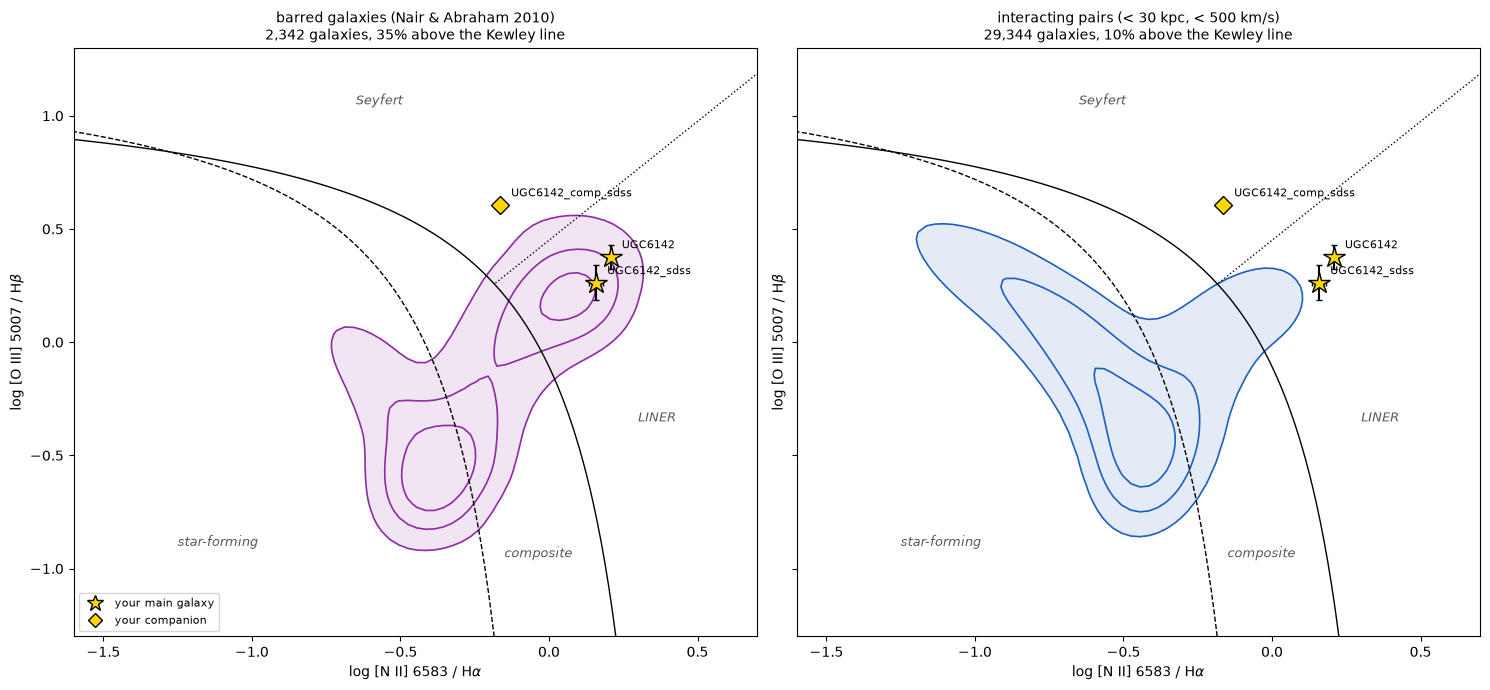

In [78]:
sdss = BC.ratios(BC.load_sdss())
sdss["pair"] = BC.sdss_pairs(sdss, 30.0, 500.0); sdss["in_nair"], sdss["bar"], sdss["napair"], sdss["inter"] = BC.nair_match(sdss)
pops = {"barred galaxies (Nair & Abraham 2010)": sdss[sdss.bar], "interacting pairs (< 30 kpc, < 500 km/s)": sdss[sdss.pair]}
sample = pd.read_csv(ROOT / "results/tables/ppxf_lines.csv"); sample = sample[(sample.min_snr_bpt >= 3) & ~sample.system.isin(MY_SYSTEMS) & ~sample.system.isin(LT.COURSE_EXCLUDE)]
fig, axs = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
for ax, (name, pop), col in zip(axs, pops.items(), ["#8e2ca3", "#1f5fbf"]):
    xc, yc, H, lev = BC.contour_levels(pop.n2.values, pop.o3.values, (-1.6, 0.7), (-1.3, 1.3), bins=0.03, smooth=3.0)   # smoothed contours, as on the slides
    ax.contourf(xc, yc, H, levels=list(lev) + [H.max()], colors=[col], alpha=0.12); ax.contour(xc, yc, H, levels=lev, colors=[col], linewidths=1.2)
    LT.bpt_frame(ax)
    #ax.plot(sample.log_nii_ha, sample.log_oiii_hb, "o", ms=4, color="0.55", mec="none", label="rest of our sample")
    for r in res[res.min_snr >= 3].itertuples():
        ax.errorbar(r.log_nii_ha, r.log_oiii_hb, xerr=r.log_nii_ha_err, yerr=r.log_oiii_hb_err, fmt="*" if r.role == "main" else "D",
                    ms=16 if r.role == "main" else 9, mfc="gold", mec="k", ecolor="k", capsize=2, zorder=6)
        ax.annotate(r.label, (r.log_nii_ha, r.log_oiii_hb), xytext=(8, 6), textcoords="offset points", fontsize=8)
    agn = (pop.o3 > LT.kewley01(pop.n2.clip(upper=0.46))) | (pop.n2 > 0.46)
    ax.set_title(f"{name}\n{len(pop):,} galaxies, {agn.mean():.0%} above the Kewley line", fontsize=10)
axs[0].plot([], [], "*", ms=12, mfc="gold", mec="k", label="your main galaxy"); axs[0].plot([], [], "D", ms=7, mfc="gold", mec="k", label="your companion"); axs[0].legend(loc="lower left", fontsize=8)
fig.tight_layout(); plt.show()
if (res.min_snr < 3).any(): print("not plotted (some line with S/N < 3):", list(res[res.min_snr < 3].label))

## Questions to answer in your report

1. **Your nucleus**: star-forming, composite or AGN? How far is it from the nearest demarcation line, in
   units of its error bar? Would the class change if Hβ were 20 % lower (lecture 1, Appendix A.3: the stellar
   absorption under Hβ)?
2. **The pair**: if both galaxies have spectra, are the two nuclei in the same class? If your galaxy has
   both a DESI (1.5″) and an SDSS (3″) spectrum, do they agree? What does a difference tell you about where
   the line emission comes from?
3. **Barred vs interacting**: which population is your nucleus more typical of? What fraction of each SDSS
   population lies above the Kewley line — do bars or interactions host more AGN?
   Careful before concluding: the two SDSS samples are not matched. Nair & Abraham classified bright
   ($g < 16$) galaxies, on average more massive and more bulge-dominated than the pairs sample, and AGN are
   more common in massive, bulge-dominated galaxies. How would you make the comparison fair?
4. **Kinematics**: compare σ⋆ and σ_gas. Is the gas colder than the stars (a disc), or hotter (an outflow)?
5. **The class's sample** (combine everyone's `my_results.csv`): is there a trend of BPT class with
   interaction stage? How many galaxies would you need to tell?